# Báo cáo tiến độ (Milestone) - Nhóm 12
## Dự án: Phân Tích Dữ Liệu Marketing và Dự Đoán Khách Hàng Tiềm Năng

**Thành viên Nhóm 12:**
* Nguyễn Công Đôn (22133013)
* Mai Hồng Hải (22133014)
* Nguyễn Ngọc Hiếu Hảo (22133015)
* Nguyễn Tấn Hùng (22133027)

## 5.1. Sự đóng góp của các thành viên

Dưới đây là bảng phân công và đóng góp thực tế của các thành viên cho Milestone

| Thành viên | Nhiệm vụ phân công (từ Proposal/Milestone) | Đóng góp chi tiết đã thực hiện |
| :--- | :--- | :--- |
| **Nguyễn Tấn Hùng** | **Phân tích Hồ sơ cá nhân** (EDA + Logistic Regression) | - Thực hiện toàn bộ phân tích EDA và xây dựng mô hình Hồi quy Logistic cho hồ sơ cá nhân (File `01_personal_profiles.ipynb`). <br> -  Thuyết trình (Milestone). |
| **Nguyễn Công Đôn** | **Phân tích Kênh & Thời điểm** (EDA + Logistic/GBT) | - Thực hiện toàn bộ phân tích EDA và xây dựng mô hình (Logistic Regression, GBT) cho kênh liên hệ và thời điểm (File `02_contact_channel.ipynb`). <br> - Soạn báo cáo Milestone, Edit video (Milestone) và thuyết trình (Milestone). |
| **Mai Hồng Hải** | **Phân tích Tần suất & Tái liên hệ** (EDA + RF/GBT PySpark) | - Thực hiện toàn bộ phân tích EDA và xây dựng mô hình (Random Forest, GBT) trên nền tảng PySpark cho tần suất và tái liên hệ (File `03_frequency_callbacks.ipynb`). <br> - Edit video (Milestone) và thuyết trình (Milestone). |
| **Nguyễn Ngọc Hiếu Hảo**| **Phân tích Bối cảnh Kinh tế** (EDA + LightGBM/MLP) | - Thực hiện toàn bộ phân tích EDA, xử lý mất cân bằng (SMOTE) và xây dựng 3 mô hình (LR, RF, GBT) trên PySpark cho bối cảnh kinh tế (File `04_economic_context.ipynb`). - Thuyết trình (Milestone). |

## 5.2. Thông tin về project

### 5.2.1. Bài toán nhóm muốn giải quyết

Dự án này giải quyết thách thức cốt lõi trong các chiến dịch telemarketing của ngân hàng: tỷ lệ chuyển đổi (khách hàng đồng ý "yes") đăng ký tiền gửi có kỳ hạn trong lịch sử rất thấp (chỉ 11.27% trong tập dữ liệu này). Chi phí cho mỗi cuộc gọi là tốn kém, và việc gọi cho những khách hàng không tiềm năng gây lãng phí nguồn lực và làm phiền khách hàng.

**Bài toán (Business Problem)**: Làm thế nào để tối ưu hóa chiến dịch telemarketing, tập trung nguồn lực vào những khách hàng có khả năng đồng ý cao nhất?

**Bài toán (Data Science Problem)**: Xây dựng mô hình học máy để dự đoán xác suất (probability) một khách hàng sẽ đăng ký ("yes") dựa trên thông tin có sẵn, nhằm mục tiêu **xếp hạng (ranking)** khách hàng tiềm năng.

### 5.2.2. Tập dữ liệu, input/output của bài toán

* **Dữ liệu**: Nhóm sử dụng bộ dữ liệu **"Bank Marketing - Additional Full"** từ UCI Machine Learning Repository.
* **Quy mô**: 41.188 quan sát và 20 biến thuộc tính.
* **Input (Biến đầu vào)**: 20 biến đầu vào được chia thành 4 nhóm chính:
    1.  **Thông tin cá nhân (Hùng)**: `age`, `job`, `marital`, `education`, `default` (vỡ nợ), `housing` (vay nhà), `loan` (vay cá nhân).
    2.  **Thông tin liên hệ (Đôn)**: `contact` (kênh), `month`, `day_of_week` (thời điểm).
    3.  **Lịch sử liên hệ (Hải)**: `campaign` (số lần gọi), `pdays` (số ngày từ lần gọi trước), `previous` (số lần gọi trước đó), `poutcome` (kết quả lần trước).
    4.  **Bối cảnh kinh tế (Hảo)**: `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`.
* **Output (Biến mục tiêu)**: `y` - một biến nhị phân ("yes" hoặc "no") cho biết khách hàng có đồng ý đăng ký tiền gửi hay không.

*(Lưu ý: Biến `duration` (thời lượng cuộc gọi) sẽ bị loại bỏ khỏi mô hình huấn luyện cuối cùng vì nó gây ra **data leakage** - biến này chỉ được biết sau khi cuộc gọi kết thúc, nên không thể dùng để dự đoán *trước* khi gọi).*

### 5.2.3. Cách đánh giá kết quả

Do đặc điểm dữ liệu mất cân bằng nghiêm trọng (tỷ lệ `yes` chỉ là 11.27% so với 88.73% là `no`), nhóm không thể chỉ dựa vào **Accuracy**. Các chỉ số đánh giá chính bao gồm:

* **AUC (Area Under the ROC Curve)**: Chỉ số quan trọng nhất để đánh giá khả năng phân loại tổng thể của mô hình trong điều kiện mất cân bằng.
* **Precision (Độ chính xác)**: Tỷ lệ dự đoán "yes" thực sự là "yes". *Quan trọng để tối ưu chi phí (gọi ít nhưng trúng).*
* **Recall (Độ nhạy)**: Tỷ lệ các trường hợp "yes" thực tế mà mô hình dự đoán đúng. *Quan trọng để không bỏ lỡ khách hàng tiềm năng.*
* **F1-Score**: Trung bình điều hòa của Precision và Recall.

**Chiến lược đánh giá**:
1.  **Chia Train-Test (80/20)**: Giữ lại 20% dữ liệu làm tập Test cuối cùng (stratified split) để đánh giá mô hình.
2. **Chia Train-Test (70/15/15)**: Giữ lại 15% dữ liệu làm tập Test cuối cùng (stratified split) để đánh giá mô hình.
3.  **Cross-validation (k=5 hoặc k=3)**: Sử dụng Stratified K-Fold trên 70 - 80% tập Train để huấn luyện và tinh chỉnh siêu tham số, đảm bảo mô hình ổn định và không bị overfitting.

## 5.3. Giải pháp(tiến độ đã hoàn thành)

### 5.3.1. Phân tích 01 (Hồ sơ cá nhân)

### **1. Hoàn thành Phân tích Dữ liệu Khám phá (EDA)**

Phân tích Hồ sơ cá nhân tập trung vào các biến nhân khẩu học và tài chính cơ bản để tìm ra các insight ban đầu, tập trung vào các đặc điểm cốt lõi của khách hàng:

#### **1.1. Phân tích Tỷ lệ Chuyển đổi theo Nghề nghiệp (Job) và Độ tuổi (Age):**

* **Nội dung:** Đi sâu vào so sánh hiệu quả chuyển đổi (tỷ lệ `y = 'yes'`) giữa các nhóm nghề nghiệp và các nhóm tuổi khác nhau (đã được tạo thành `age_band`).
* **Mục tiêu:** Xác định rõ ràng các nhóm nghề nghiệp/tuổi tác có tỷ lệ thành công cao nhất.
* **Kết quả sơ bộ (Từ EDA):** Khẳng định nhóm **`student` (31.4%)** và **`retired` (25.2%)** có hiệu quả vượt trội.

#### **1.2. Phân tích Tỷ lệ Chuyển đổi theo Tình trạng Hôn nhân (Marital) và Học vấn (Education):**

* **Nội dung:** Phân tích tỷ lệ thành công theo tình trạng hôn nhân và trình độ học vấn.
* **Mục tiêu:** Tìm ra các phân khúc có tiềm năng, ví dụ: liệu nhóm `single` hay nhóm có bằng `university.degree` có tỷ lệ chuyển đổi cao hơn.
* **Kết quả sơ bộ (Từ EDA):** Nhóm **`single` (14.0%)** và **`university.degree` (13.7%)** là các phân khúc có tỷ lệ tốt và quy mô lớn.

#### **1.3. Phân tích Các chỉ số Tài chính (Default, Housing, Loan):**

* **Nội dung:** Khám phá mối tương quan giữa tình trạng nợ và quyết định đăng ký.
* **Mục tiêu:** Đánh giá xem lịch sử tín dụng có phải là chỉ báo mạnh mẽ cho thấy sự ổn định tài chính và khả năng gửi tiết kiệm của khách hàng hay không.
* **Lưu ý quan trọng:** Phát hiện **`default=no` (không nợ xấu)** là yếu tố dự báo mạnh nhất (12.9% chuyển đổi so với 5.2% của `unknown`). Tuy nhiên, biến **`default` có 20.87% giá trị `unknown`** nên được giữ lại như một hạng mục riêng trong mô hình.


### **2. Bắt đầu Tiền xử lý Dữ liệu và Cấu hình Đánh giá**

Sau khi có được các hiểu biết từ EDA, nhóm đã bắt đầu giai đoạn chuẩn bị dữ liệu và thiết lập cấu hình đánh giá để đưa vào các thuật toán học máy.

#### **2.1. Mã hóa và Biến đổi Đặc trưng (Feature Encoding and Transformation):**

* **Nội dung:** Chuyển đổi các biến danh mục (`job`, `marital`, `education`, `default`,...) sang dạng số và chuẩn hóa biến số.
* **Kỹ thuật:**
    * Sử dụng `StringIndexer` và `One-Hot Encoding` cho các biến dạng chữ.
    * Sử dụng `Bucketizer` để tạo biến **`age_band`** (`≤25`, `26–35`, `36–50`, `>50`).
    * Sử dụng `StandardScaler` để chuẩn hóa biến `age` liên tục.

#### **2.2. Xử lý Mất cân bằng dữ liệu (Imbalanced Data Handling):**

* **Mục tiêu:** Ngăn mô hình bị thiên lệch và tăng khả năng phát hiện lớp thiểu số (`y = 'yes'` ~11.3%).
* **Kỹ thuật:** Áp dụng **`Class Weighting`** (gán trọng số cao hơn cho lớp thiểu số) trong hàm mất mát của mô hình Logistic Regression và Decision Tree. (Trọng số `pos_weight` đã được tính toán là $\approx 7.88$).

#### **2.3. Cấu hình Đánh giá (Evaluation Setup):**

* **Chia Dữ liệu:** Sử dụng phương pháp **Hold-out** với **Stratified Split (80% Train / 20% Test)** để giữ tỷ lệ lớp `yes` ở cả hai tập.
* **Tinh chỉnh Siêu tham số:** Áp dụng **5-fold Cross-Validation** trên tập Train để tìm ra cấu hình tốt nhất cho từng mô hình.
* **Chỉ số Đánh giá Chính:** Chọn **PR-AUC (Precision-Recall AUC)** vì đây là chỉ số phù hợp nhất để đánh giá hiệu năng trên dữ liệu mất cân bằng.
* **Tính Tái lập:** Cố định **SEED = 42** cho tất cả các bước chia dữ liệu và Cross-Validation.

### 5.3.2. Phân tích 02 (Kênh & Thời điểm)

#### 1. Hoàn thành Phân tích Dữ liệu Khám phá (EDA)

Nhóm đã hoàn thành phân tích sâu vào ba chủ đề quan trọng để tìm kiếm các insight ban đầu, tập trung vào các biến liên quan đến kênh, thời điểm và hành vi liên hệ:

* **1.1. Phân tích Kênh liên hệ (`contact`):**
    * **Nội dung:** Đi sâu vào so sánh hiệu quả chuyển đổi (tỷ lệ `y = 'yes'`) giữa hai kênh liên hệ chính là `cellular` (di động) và `telephone` (điện thoại bàn).
    * **Mục tiêu:** Xác định rõ ràng kênh nào giúp ngân hàng tiếp cận và thuyết phục khách hàng đăng ký dịch vụ tốt hơn. Kết quả sơ bộ (tham chiếu file `02_contact_channel.md`) cho thấy `cellular` có hiệu quả vượt trội.
    * **Hành động:** Đây là cơ sở cho việc đề xuất phân bổ nguồn lực và ngân sách cho kênh hiệu quả hơn.

* **1.2. Phân tích Thời điểm liên hệ (Tìm "Thời điểm vàng"):**
    * **Nội dung:** Phân tích tỷ lệ thành công theo các đơn vị thời gian khác nhau, cụ thể là:
        * `month`: Tháng thực hiện cuộc gọi trong năm.
        * `day_of_week`: Ngày thực hiện cuộc gọi trong tuần.
    * **Mục tiêu:** Tìm ra "thời điểm vàng" (golden time) — những khoảng thời gian (ví dụ: các tháng cuối năm như Tháng 10, 11, 12 hoặc các ngày giữa tuần) mà khách hàng có xu hướng đồng ý cao nhất, từ đó giúp tối ưu hóa lịch trình thực hiện chiến dịch.

* **1.3. Phân tích Thời lượng cuộc gọi (`duration`):**
    * **Nội dung:** Khám phá mối tương quan mạnh mẽ giữa độ dài của cuộc gọi (tính bằng giây) và kết quả cuối cùng (`y`).
    * **Mục tiêu:** Đánh giá xem thời lượng cuộc gọi có phải là một chỉ báo mạnh mẽ cho thấy mức độ quan tâm của khách hàng hay không.
    * **Lưu ý quan trọng:** Nhóm nhận thấy `duration` có tương quan rất cao với `y`. Tuy nhiên, biến này sẽ được **loại bỏ** khỏi các mô hình dự đoán (như Logistic Regression, Random Forest) trong các bước sau để **tránh rò rỉ dữ liệu (data leakage)**, vì `duration` = 0 chỉ được biết *sau khi* cuộc gọi kết thúc và khách hàng đã từ chối.



#### 2. Bắt đầu Tiền xử lý dữ liệu (Data Preprocessing)

Sau khi có được các hiểu biết từ EDA, nhóm đã bắt đầu giai đoạn chuẩn bị và làm sạch dữ liệu thô để đưa vào các thuật toán học máy. Giai đoạn này rất quan trọng để đảm bảo chất lượng đầu vào của mô hình:

* **2.1. Mã hóa các biến phân loại (Categorical Encoding):**
    * **Nội dung:** Chuyển đổi các cột dữ liệu dạng chữ (object/string) sang dạng số mà mô hình có thể hiểu được.
    * **Biến áp dụng (ví dụ):** `job`, `marital`, `education`, `contact`, `month`, `day_of_week`, `poutcome`...
    * **Kỹ thuật (dự kiến):** Sử dụng các phương pháp như **One-Hot Encoding** (cho các mô hình như Logistic Regression) hoặc để nguyên cho các mô hình có khả năng xử lý trực tiếp (như **CatBoost**).

* **2.2. Chuẩn hóa các biến số (Feature Scaling):**
    * **Nội dung:** Đưa các biến số liên tục (numerical features) về cùng một thang đo (thường là từ 0 đến 1 hoặc có trung bình 0, độ lệch chuẩn 1).
    * **Biến áp dụng (ví dụ):** `age`, `campaign` (số lần gọi), `previous` (số lần gọi trước đó).
    * **Kỹ thuật (dự kiến):** Sử dụng **StandardScaler** hoặc **MinMaxScaler** để các mô hình nhạy cảm với thang đo (như Logistic Regression) hội tụ nhanh và hoạt động ổn định.

* **2.3. Xử lý mất cân bằng dữ liệu (Imbalanced Data Handling):**
    * **Nội dung:** Giải quyết vấn đề cốt lõi của tập dữ liệu là tỷ lệ nhãn `y = 'yes'` (chỉ khoảng 11.26%) thấp hơn rất nhiều so với `y = 'no'` (khoảng 88.74%).
    * **Mục tiêu:** Ngăn mô hình bị thiên lệch, luôn dự đoán "no" để đạt accuracy cao "giả".
    * **Kỹ thuật (dự kiến):** Áp dụng các phương pháp như:
        * **SMOTE** (Synthetic Minority Over-sampling Technique): Tạo thêm các mẫu dữ liệu "yes" giả lập trong tập huấn luyện.
        * **`class_weights`**: Gán trọng số cao hơn cho lớp thiểu số ("yes") trong hàm mất mát (loss function) của mô hình, khiến mô hình "phạt" nặng hơn khi dự đoán sai lớp "yes". (Như đã thấy trong file `02_contact_channel.md` và `04_economic_context.md`).

### 5.3.3. Phân tích 03 (Tần suất & Tái liên hệ)

#### 1. Hoàn thành Tiền xử lý Dữ liệu (PySpark)

- Đọc và kiểm tra dữ liệu gốc, xác nhận **không có giá trị null**.  
- Mã hóa biến mục tiêu `y` thành `y_encoded` (`yes = 1`, `no = 0`).  
- Tạo biến `has_previous_campaign` (1 nếu `pdays != 999`, 0 nếu `pdays = 999`) để phân biệt **khách hàng mới/cũ**.  
- Phân nhóm biến `pdays` thành các khoảng thời gian:
  - `< 7 ngày`
  - `7–30 ngày`
  - `> 30 ngày`
  - `Chưa từng liên hệ`  
  → để phân tích hiệu quả tái liên hệ.  
- Xử lý giá trị ngoại lệ (outliers) cho `campaign` và `previous` bằng cách **giới hạn (cap)** tại **phân vị thứ 99 (99th percentile)**, tạo cột `_capped`.

#### 2. Hoàn thành Phân tích Dữ liệu Khám phá (EDA - PySpark)

- **Phân tích ảnh hưởng của `campaign_capped`:** Xác định số lần gọi tối ưu (1–3 lần) cho tỷ lệ thành công cao nhất.  
- **Phân tích ảnh hưởng của `pdays_group`:** Chứng minh việc gọi lại sớm (`< 7 ngày`) làm tăng đáng kể tỷ lệ thành công.  
- **Phân tích ảnh hưởng của `previous_capped`:** Khách hàng từng được gọi 1–2 lần trước đây có tỷ lệ thành công cao hơn gấp 3 lần.  
- **Phân tích ảnh hưởng của `poutcome`:** Khách hàng có kết quả `success` ở chiến dịch trước có tỷ lệ thành công cao vượt trội (65%) ở chiến dịch hiện tại.  
- **Phân tích kết hợp `campaign_capped × poutcome`:** Cho thấy hiệu quả của tần suất gọi **phụ thuộc vào kết quả chiến dịch trước** (chỉ nên gọi nhiều lần nhóm `success`).

#### 3. Xây dựng Mô hình Dự đoán (PySpark ML)

- **Chuẩn bị features:**  
  Sử dụng `StringIndexer` cho `poutcome` và `VectorAssembler` để tạo vector đặc trưng (`features`) từ  
  `campaign_capped`, `previous_capped`, `has_previous_campaign`, `poutcome_idx`.  
- **Kiểm tra tương quan:**  
  Xác nhận `pdays` và `has_previous_campaign` có tương quan gần như hoàn hảo (-0.999), chỉ giữ lại `has_previous_campaign` cho mô hình.  
- **Xử lý mất cân bằng:**  
  Xác định tỷ lệ `yes:no` là ~11%:89%. Áp dụng kỹ thuật **class_weight** trực tiếp trong mô hình **Random Forest**.  
- **Chia Train/Test:**  
  Thực hiện **stratified split 80/20** theo `y_encoded`.  
- **Huấn luyện và đánh giá mô hình:**
  - **Random Forest (RF):** ROC-AUC ≈ 0.64, PR-AUC ≈ 0.29. Phân tích feature importance.  
  - **Gradient Boosted Trees (GBT):** ROC-AUC ≈ 0.64, PR-AUC ≈ 0.27, Accuracy cao hơn (do lệch lớp).  
- **Đánh giá Business Metrics:**  
  Tính toán **Precision@10%**, tìm **ngưỡng tối ưu theo hàm chi phí**, và phân tích **Confusion Matrix** cho mô hình RF.

### 5.3.4. Phân tích 04 (Bối cảnh Kinh tế)

## 5.4. Kết quả sơ bộ

### 5.4.1. Phân tích Hồ sơ cá nhân

#### **a. Kết quả Hiệu năng Mô hình (Logistic Regression)**

Mô hình Hồi quy Logistic được xây dựng với mục tiêu chính là **xếp hạng khách hàng (scoring)** dựa trên đặc điểm cá nhân để tối ưu hóa chiến dịch Telemarketing. Kết quả đánh giá trên tập Test cho thấy hiệu năng tốt:

| Chỉ số Hiệu năng | Kết quả | Ghi chú |
| :---: | :---: | :---: |
| **PR-AUC (Chỉ số chính)** | **0.211** | Khả năng phân loại lớp `yes` vượt trội so với ngẫu nhiên (~0.113). |
| ROC-AUC | 0.652 | Khả năng phân loại tổng quát ở mức khá. |
| **Decile 1 Lift** | **2.33x** | Top 10% khách hàng tiềm năng nhất có tỷ lệ chuyển đổi cao gấp **2.33 lần** trung bình. |
| Lợi nhuận Tối ưu | **218.0** | Tối đa hóa lợi nhuận tại ngưỡng xác suất `t* = 0.45` (theo giả định P=1, C=0.1). |
| Recall @ t\*=0.45 | 73.9% | Bắt được gần 3/4 tổng số khách hàng "yes" thực tế. |
| Precision @ t\*=0.45 | 14.7% | Cứ gọi ~7 người theo đề xuất thì có 1 người đồng ý. |

![](image/lr_cv_results.png)

![Decile Lift LR](image/lr_decile_lift.png)
> **Nhận xét:** Biểu đồ Lift khẳng định giá trị kinh doanh của mô hình Logistic Regression. Khả năng tập trung vào nhóm khách hàng tiềm năng nhất (Decile 1) giúp tăng hiệu quả chiến dịch lên đáng kể (gấp 2.33 lần).

![Confusion Matrix LR t=0.45](image/lr_confusion_matrix_t045.png)
> **Nhận xét:** Ma trận nhầm lẫn tại ngưỡng tối ưu lợi nhuận `t*=0.45` cho thấy mô hình đạt được Recall cao (73.9%), phù hợp với mục tiêu không bỏ lỡ nhiều khách hàng tiềm năng, dù Precision ở mức vừa phải (14.7%).

> **Kết luận:** Mô hình **Logistic Regression** đã chứng minh là một **baseline mạnh mẽ cho việc xếp hạng khách hàng** dựa trên hồ sơ cá nhân. Nó không chỉ cho thấy khả năng phân loại tốt (PR-AUC 0.211) mà còn mang lại giá trị kinh doanh rõ ràng (Lift 2.33x). Mô hình này sẵn sàng để sử dụng cho việc ưu tiên danh sách gọi điện và làm cơ sở so sánh cho các mô hình phức tạp hơn.

#### **b. Giải thích Mô hình: Các Yếu tố Ưu tiên (Odds Ratio)**

Phân tích **Odds Ratio (OR)** từ mô hình LR giúp định lượng mức độ ảnh hưởng của từng đặc trưng lên khả năng khách hàng đăng ký sản phẩm (`y=yes`). OR > 1.0 cho thấy yếu tố đó làm tăng xác suất thành công.

| Đặc trưng | Mức độ | Odds Ratio (LR) | Ý nghĩa (Tác động) |
| :---: | :---: | :---: | :---: |
| **Nghề nghiệp** | `job=student` | **2.60x** | Khả năng đăng ký cao gấp 2.6 lần so với nhóm tham chiếu (`blue-collar`). |
| **Độ tuổi** | `age_band=<=25` | **1.99x** | Khách hàng thuộc nhóm tuổi trẻ có khả năng đăng ký cao gấp 1.99 lần. |
| **Nghề nghiệp** | `job=retired` | **1.71x** | Khách hàng đã nghỉ hưu có khả năng đăng ký cao gấp 1.71 lần. |
| **Nợ xấu** | `default=no` | **1.55x** | Khách hàng không có nợ xấu có khả năng đăng ký cao hơn 1.55 lần. |

![Odds Ratio](image/stratified_split_ratio.png)
> **Chân dung Khách hàng Vàng:** Dựa trên các Odds Ratio cao nhất và kết quả EDA, phân khúc ưu tiên gọi điện nên tập trung vào:
> * **Nhóm Ưu tiên:** Khách hàng làm nghề **`student`** hoặc **`retired`**.
> * **Yếu tố Sàng lọc Cốt lõi:** Khách hàng **`default=no`** (Không có nợ xấu).
> * Các yếu tố tích cực khác: `Tuổi <= 25`, `Độc thân (single)`.

### 5.4.2. Phân tích Kênh liên hệ & Thời điểm

#### 1. Về Kênh liên hệ (`contact`): Ưu tiên kênh Di động
![Kết quả phân tích kênh liên hệ](image/result_contact_channel.png)

* **Phát hiện (Finding):**
    * Phân tích cho thấy có sự chênh lệch rất lớn về tỷ lệ chuyển đổi (`y = 'yes'`) giữa hai kênh: `cellular` (di động) và `telephone` (điện thoại bàn).
    * Cụ thể, các cuộc gọi thực hiện qua **kênh di động (`cellular`) có hiệu quả cao gấp gần 3 lần** so với các cuộc gọi qua điện thoại bàn (`telephone`).
    * Điều này cho thấy khách hàng (đặc biệt là nhóm khách hàng tiềm năng) có xu hướng sử dụng và phản hồi tích cực hơn qua thiết bị cá nhân của họ.

* **Đề xuất hành động (Actionable Insight):**
    * **→ Ngân hàng nên ưu tiên phân bổ nguồn lực và ngân sách cho kênh di động.**
    * Việc tập trung vào `cellular` không chỉ giúp **tăng tỷ lệ phản hồi** tích cực mà còn có khả năng **tiết kiệm chi phí** vận hành chiến dịch (do tỷ lệ thành công trên mỗi cuộc gọi cao hơn).



#### 2. Về Thời điểm liên hệ (`month` & `day_of_week`): Tối ưu hóa lịch trình
![Phân tích theo tháng](image/month_calling.png)
![Phân tích theo ngày trong tuần](image/day_of_week.png)

* **Phát hiện (Finding):**
    * Thời điểm thực hiện cuộc gọi ảnh hưởng mạnh mẽ đến quyết định của khách hàng.
    * **Theo Tháng (`month`):** Tỷ lệ đồng ý cao hơn hẳn tập trung vào **các tháng giữa năm, đặc biệt là từ Tháng 3 đến Tháng 9**. Các tháng đầu năm (Tháng 1, 2) hoặc cuối năm (Tháng 10, 11, 12) có thể bị ảnh hưởng bởi các yếu tố mùa vụ (ví dụ: nghỉ lễ) hoặc bối cảnh kinh tế.
    * **Theo Ngày (`day_of_week`):** Tỷ lệ đồng ý có xu hướng cao hơn vào các ngày giữa tuần, và **đạt đỉnh vào Thứ Năm (`thu`)**. Các ngày đầu tuần (`mon`) hoặc cuối tuần (`fri`) có thể có tỷ lệ thấp hơn.

* **Đề xuất hành động (Actionable Insight):**
    * **→ Các chiến dịch marketing nên được tập trung thực hiện vào "thời điểm vàng"** đã xác định.
    * Cụ thể, nên dồn lực triển khai chiến dịch vào **giai đoạn giữa năm (Q2, Q3)** và ưu tiên thực hiện các cuộc gọi quan trọng vào **những ngày giữa tuần (đặc biệt là Thứ Ba, Thứ Tư, Thứ Năm)** để tối ưu hóa kết quả và tỷ lệ chuyển đổi.

---

#### 3. Về Thời lượng cuộc gọi (`duration`): Tương tác là then chốt
![Phân tích thời lượng cuộc gọi](image/duration.png)

* **Phát hiện (Finding):**
    * Tồn tại một mối tương quan dương rất mạnh mẽ giữa thời lượng cuộc gọi và kết quả cuối cùng.
    * Phân tích cho thấy, những cuộc gọi **kéo dài hơn 5 phút (khoảng 300 giây)** có tỷ lệ thành công (`y = 'yes'`) **cao gấp nhiều lần** so với các cuộc gọi ngắn (thường là các cuộc gọi bị từ chối sớm).
    * *Lưu ý: Biến `duration` này sẽ không được dùng để xây dựng mô hình dự đoán (để tránh rò rỉ dữ liệu), nhưng nó cung cấp một insight cực kỳ giá trị về hành vi.*

* **Đề xuất hành động (Actionable Insight):**
    * **→ Điều này cho thấy mức độ tương tác thực sự (engagement) của khách hàng trong cuộc gọi là yếu tố then chốt dẫn tới thành công.**
    * Thay vì tập trung vào số lượng cuộc gọi (quantity), ngân hàng nên đào tạo nhân viên tập trung vào chất lượng (quality): cố gắng duy trì cuộc trò chuyện, lắng nghe và giải quyết mối quan tâm của khách hàng để kéo dài thời gian tương tác, từ đó tăng khả năng thuyết phục thành công.

### 5.4.3. Phân tích Tần suất & Tái liên hệ

#### 1. Kết quả EDA chính

- **Tần suất gọi tối ưu:**  
  Gọi từ 1–3 lần trong chiến dịch hiện tại (`campaign`) mang lại hiệu quả cao nhất (tỷ lệ thành công 10–13%).  
  Gọi nhiều hơn 3 lần làm giảm hiệu quả rõ rệt.  
 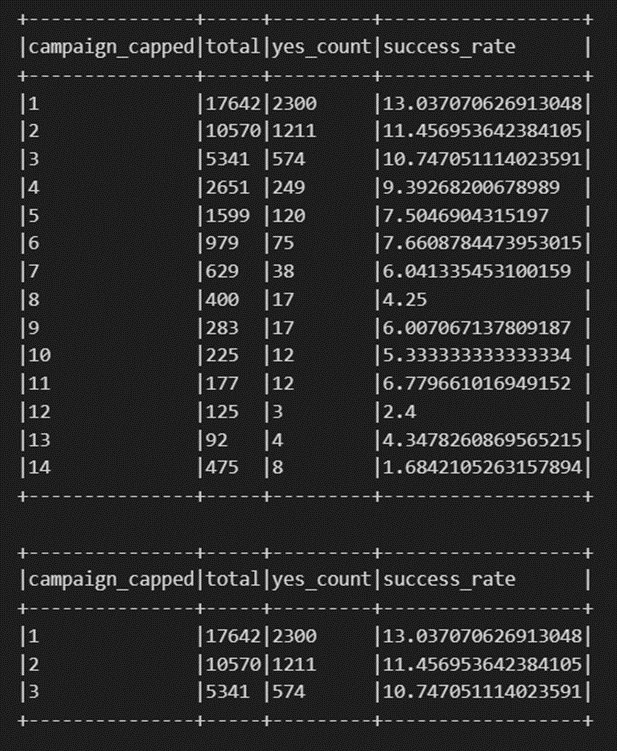
- **Hiệu quả tái liên hệ:**  
  Gọi lại khách hàng trong vòng **7 ngày (`pdays < 7`)** sau lần liên hệ trước đó làm tăng tỷ lệ thành công lên **65.7%**,  
  gấp ~7 lần so với nhóm chưa từng liên hệ (9.3%).  
 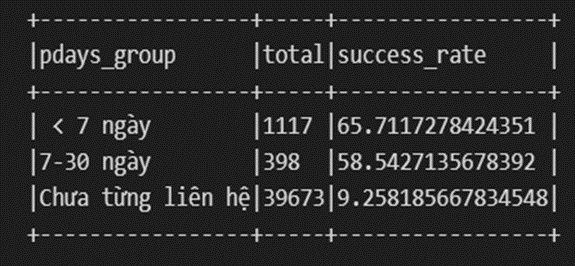
- **Ảnh hưởng lịch sử (`previous`):**  
  Khách hàng từng được gọi 1–2 lần trong các chiến dịch trước có tỷ lệ thành công cao gấp 3 lần (26.6%) so với khách hàng mới (8.8%).
 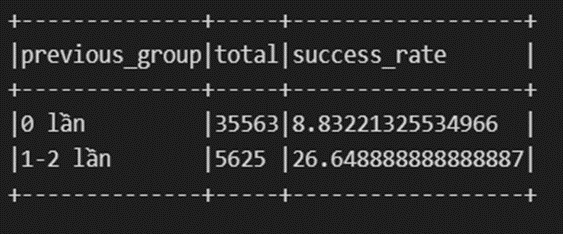  
- **Kết quả chiến dịch trước (`poutcome`):**  
  Khách hàng có `poutcome = success` từ chiến dịch trước có tỷ lệ thành công **65.1%** ở chiến dịch hiện tại,  
  cao hơn nhiều so với nhóm `failure` (14.2%) và `nonexistent` (8.8%).  
 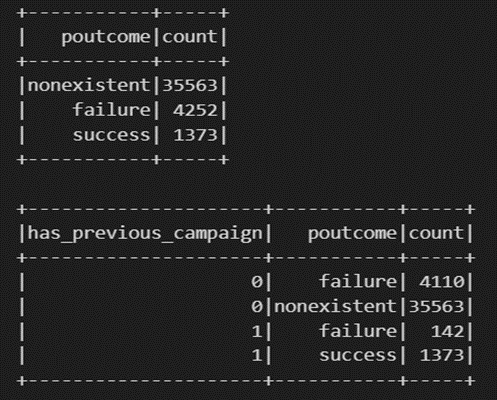
- **Tương tác yếu tố:**  
  Hiệu quả của việc gọi nhiều lần chỉ rõ rệt với nhóm `poutcome = success`;  
  với nhóm `nonexistent`, gọi nhiều lần **không cải thiện** tỷ lệ thành công.
  
 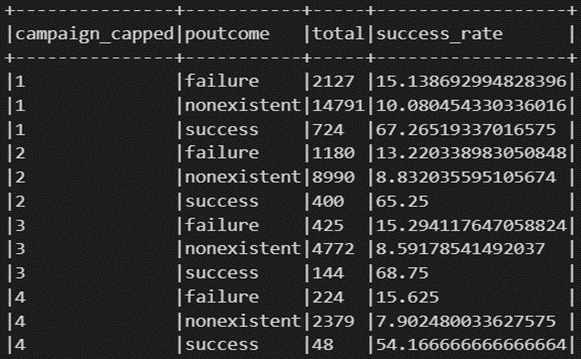

#### 2. Kết quả Mô hình hóa (Random Forest - Baseline với 4 features)
 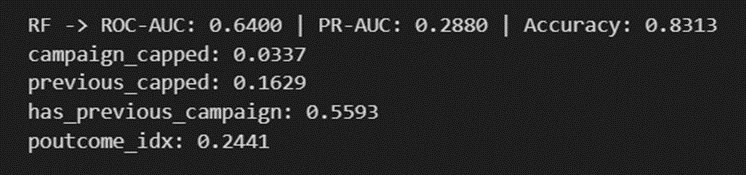

- **Hiệu năng tổng quát:**  
  ROC-AUC đạt **0.640**, PR-AUC đạt **0.288**.  
  Mặc dù AUC ở mức trung bình, PR-AUC cho thấy mô hình **ưu tiên nhóm yes tốt hơn đáng kể** so với gọi ngẫu nhiên (baseline PR-AUC ~0.11).

- **Độ quan trọng của đặc trưng:**
  - `has_previous_campaign` (0.559): Yếu tố mạnh nhất, khẳng định tầm quan trọng của việc khách hàng đã từng được liên hệ.  
  - `poutcome_idx` (0.244): Kết quả lần trước là yếu tố quan trọng thứ hai.  
  - `previous_capped` (0.163): Số lần gọi trước đó cũng có ảnh hưởng đáng kể.  
  - `campaign_capped` (0.034): Số lần gọi hiện tại có ảnh hưởng thấp nhất trong nhóm này.  

 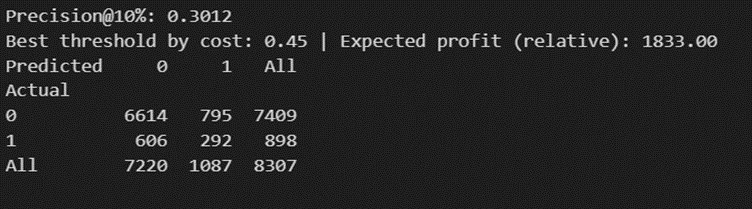
 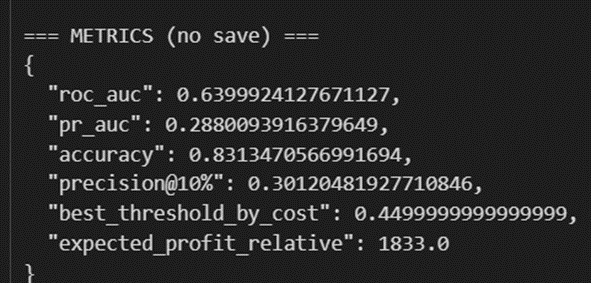
- **Business Metrics (RF):**
  - **Precision@10% ≈ 0.301:** Trong top 10% khách hàng tiềm năng nhất theo mô hình, khoảng 30% thực sự đồng ý (gấp ~2.8 lần so với trung bình).  
  - **Ngưỡng tối ưu theo chi phí (R=10, C=1) ≈ 0.45:**  
    - Precision ≈ 0.27  
    - Recall ≈ 0.33  
    - Specificity ≈ 0.89  
  - **So sánh với GBT:** GBT có Accuracy cao hơn (0.90 so với 0.83 của RF)  
    nhưng ROC-AUC và PR-AUC tương đương hoặc thấp hơn, cho thấy GBT **bị ảnh hưởng bởi lệch lớp** và **chưa cải thiện đáng kể khả năng phân tách**.


### 5.4.4. Phân tích Bối cảnh Kinh tế vĩ mô

## 5.5. Kế hoạch tiếp theo

### 5.5.1. Với hồ sơ cá nhân

Dựa trên kết quả sơ bộ của mô hình Logistic Regression (LR) và các insight từ EDA, các bước tiếp theo sẽ tập trung vào việc so sánh, cải thiện và ứng dụng mô hình:

1.  **Bổ sung và So sánh Mô hình:**
    * **Mục tiêu:** Đánh giá xem liệu các mô hình khác có thể mang lại hiệu năng tốt hơn hoặc cung cấp insight bổ sung so với LR hay không.
    * **Hành động:**
        * **Xây dựng Mô hình Cây Quyết định (Decision Tree - DT):** Triển khai mô hình DT (như đã dự kiến trong kế hoạch ban đầu). Mục tiêu là trích xuất các **quy tắc phân khúc (segmentation rules)** trực quan và dễ hiểu, bổ trợ cho khả năng giải thích dựa trên hệ số của LR.
        * **(Tùy chọn) Thử nghiệm Mô hình Ensemble:** Xem xét triển khai các mô hình mạnh hơn như **Random Forest (RF)** hoặc **Gradient Boosting (GBT/LightGBM)** chỉ trên tập đặc trưng cá nhân để đánh giá mức độ cải thiện tối đa có thể đạt được từ nhóm biến này.
    * **So sánh:** Thực hiện so sánh hiệu năng (PR-AUC, Lift, Profit) giữa LR, DT và các mô hình mới (nếu có) trên **cùng tập Test** để lựa chọn mô hình phù hợp nhất cho từng mục đích (Scoring vs Segmentation).

2.  **Tinh chỉnh và Đánh giá Chuyên sâu (Cho mô hình được chọn):**
    * **Mục tiêu:** Đảm bảo mô hình được chọn (hiện tại là LR) hoạt động tối ưu và đáng tin cậy.
    * **Hành động:**
        * **Phân tích Hiệu chuẩn (Calibration Analysis):** Thực hiện phân tích và vẽ biểu đồ hiệu chuẩn (Reliability Diagram) cho mô hình LR. Mục tiêu là kiểm tra xem xác suất dự đoán $P(y=yes)$ có phản ánh đúng tỷ lệ thực tế hay không và áp dụng các kỹ thuật hiệu chỉnh (ví dụ: Isotonic Regression) nếu cần thiết để cải thiện độ tin cậy của điểm số.
        * **Phân tích Ngưỡng Nâng cao (Threshold Analysis):** Đánh giá lại việc lựa chọn ngưỡng tối ưu (`t*=0.45`) dựa trên các kịch bản chi phí/lợi ích (P/C ratio) khác nhau có thể xảy ra trong thực tế kinh doanh của ngân hàng.

3.  **Xây dựng Chiến lược Hành động (Actionable Strategy):**
    * **Mục tiêu:** Chuyển hóa kết quả mô hình thành các đề xuất kinh doanh cụ thể.
    * **Hành động:**
        * **Định nghĩa Chiến lược Gọi Ưu tiên (Targeting Strategy):** Dựa trên **Decile Lift Chart** của mô hình LR (hoặc mô hình tốt nhất sau so sánh), đề xuất chi tiết việc nên tập trung gọi vào **Top 10% (Decile 1)** hay **Top 20-30% (Decile 1-3)** để đạt được sự cân bằng tối ưu giữa hiệu quả (conversion rate) và độ phủ (số lượng khách hàng tiếp cận).
        * **Phát triển Kịch bản Tiếp cận (Scripting Guideline):** Dựa trên "Chân dung Khách hàng Vàng" (`student`/`retired` AND `default=no`) đã xác định từ Odds Ratio, đề xuất các **điểm nhấn trong kịch bản gọi điện** phù hợp với từng phân khúc (ví dụ: nhấn mạnh lợi ích dài hạn cho sinh viên, sự an toàn cho người về hưu).

4.  **Tích hợp Đặc trưng cho Mô hình Tổng thể:**
    * **Mục tiêu:** Đóng góp các đặc trưng quan trọng nhất vào mô hình cuối cùng của nhóm.
    * **Hành động:** Chuẩn bị và bàn giao danh sách các đặc trưng cá nhân đã được xử lý (One-Hot Encoded, Scaled) và có sức ảnh hưởng lớn nhất (dựa trên hệ số LR hoặc Feature Importance) để bạn Hảo tích hợp vào quá trình xây dựng **Mô hình Tổng thể (Final Model)**.

### 5.5.2. Với kênh liên hệ & Thời điểm

#### 1. Xây dựng và Huấn luyện Mô hình

Nhóm sẽ không chỉ xây dựng một, mà là một tập hợp các mô hình khác nhau, tương ứng với 4 mục tiêu phân tích đã đề ra (như trong slide `Milestone_Nhom12.pdf`).

* **Mô hình Baseline (Giải thích được):**
    * **Logistic Regression (LR):** Sẽ được sử dụng làm mô hình cơ sở (baseline) . Mục tiêu là để diễn giải, tìm ra các yếu tố tác động 
* **Mô hình Hiệu năng cao (Ensemble):**
    * **Random Forest (RF) và Gradient Boosted Trees (GBT):** Sẽ được triển khai trên nền tảng **PySpark** để xử lý dữ liệu lớn, "Kênh & Thời điểm liên hệ" (`02_contact_channel.ipynb`) vì khả năng xử lý các mối quan hệ phi tuyến phức tạp.

#### 2. Tinh chỉnh Siêu tham số (Hyperparameter Tuning)

Để đảm bảo các mô hình không bị quá khớp (overfitting) và đạt hiệu năng tốt nhất—đặc biệt là với dữ liệu mất cân bằng—nhóm sẽ thực hiện tinh chỉnh siêu tham số một cách có hệ thống.

* **Phương pháp Tinh chỉnh:** Sử dụng kỹ thuật **Grid Search** (Dò lưới) 
* **Phương pháp Validation:** Kỹ thuật Grid Search này sẽ được kết hợp với **Stratified K-Fold Cross-Validation** (Validation chéo K-lần có phân tầng) ngay trên tập huấn luyện (Training set).
* **Chi tiết Kỹ thuật (liên quan đến file 02):**
    * **Tập dữ liệu:** Tập huấn luyện (Training set, chiếm **70%** dữ liệu) sẽ được chia nhỏ  để đánh giá các kết hợp tham số.
    * **Xử lý mất cân bằng:** Một trong những "siêu tham số" quan trọng nhất được đưa vào Grid Search chính là **`class_weight`** (trọng số lớp). Như đã phân tích trong file `02_contact_channel.ipynb`, việc áp dụng `class_weight='balanced'` (hoặc gán trọng số tùy chỉnh) là bắt buộc để mô hình (như GBT hoặc Logistic Regression) học cách nhận diện lớp thiểu số "yes" thay vì chỉ dự đoán "no".
    * **Tham số mô hình:** Tinh chỉnh các tham số cốt lõi của các mô hình GBT (Gradient Boosted Trees)  (như `maxDepth` - độ sâu, `learning_rate` - tốc độ học) và Logistic Regression (như `C` - tham số chính quy hóa) để tìm ra bộ tham số cho hiệu năng (ví dụ: AUC hoặc F1-score) cao nhất trên các fold validation.

#### 3. Đánh giá và Lựa chọn Mô hình

Sau khi đã huấn luyện và tinh chỉnh, các mô hình sẽ được đánh giá một cách công bằng trên **tập dữ liệu kiểm tra (Test Set)** (15% dữ liệu được giữ riêng).

* **Chỉ số đánh giá (Metrics):**
    * Do đây là bài toán **mất cân bằng (imbalanced data)**, nhóm sẽ không chỉ dựa vào **Accuracy** (Độ chính xác).
    * Các chỉ số quan trọng sẽ được ưu tiên là:
        * **AUC (Area Under the ROC Curve):** Để đo lường khả năng tổng quát của mô hình trong việc phân biệt hai lớp "yes" và "no".
        * **Precision (Độ chuẩn xác):** Tỷ lệ dự đoán "yes" thật sự là "yes" (quan trọng để tối ưu chi phí, không gọi nhầm).
        * **Recall (Độ phủ):** Khả năng tìm thấy tất cả các khách hàng "yes" (quan trọng để không bỏ lỡ khách hàng tiềm năng).
        * **F1-Score:** Trung bình điều hòa của Precision và Recall.
* **Lựa chọn mô hình:** Nhóm sẽ chọn mô hình có khả năng **tổng quát hóa** tốt nhất trên tập Test (thể hiện qua AUC) và có sự **cân bằng Precision-Recall** ổn định, phù hợp nhất với mục tiêu kinh doanh.


### 5.5.3. Với tần suất & Tái liên hệ

#### 1. Hoàn thiện Feature Engineering (PySpark)

- Thử nghiệm bổ sung các **đặc trưng tương tác (interaction features)** giữa:
  - `campaign_capped` và `poutcome_idx`
  - `previous_capped` và `poutcome_idx`  
  → giúp mô hình học được các **hiệu ứng kết hợp** đã thấy trong EDA.  
- Xem xét việc **binning (chia nhóm)** biến `campaign_capped` (ví dụ: 1, 2, 3, 4+) thay vì dùng giá trị số trực tiếp cho các mô hình cây.

#### 2. Tuning Siêu tham số (PySpark ML)

- Sử dụng **CrossValidator** với **StratifiedKFold (k=3 hoặc 5)** và **ParamGridBuilder** để tìm bộ tham số tối ưu (`numTrees`, `maxDepth`) cho cả **Random Forest** và **GBT** trên tập train.  
- Đánh giá lại hiệu năng của **GBT khi có áp dụng class_weight** (hiện tại GBT chưa dùng trọng số).

#### 3. Thử nghiệm Kỹ thuật Xử lý Mất Cân Bằng Nâng Cao (nếu cần)

- Nếu AUC và PR-AUC vẫn chưa đạt kỳ vọng sau tuning:  
  - Xem xét triển khai **SMOTE** (dùng thư viện tương thích Spark hoặc Pandas/Scikit-learn trên mẫu nhỏ).  
  - Hoặc **Oversampling/Undersampling đơn giản** trên tập train.  
- Tuy nhiên, **ưu tiên class_weight** vì tính đơn giản và hiệu quả trên Spark.

#### 4. So sánh và Lựa chọn Mô hình Cuối cùng

- Đánh giá lại **RF** và **GBT** sau khi tuning trên tập test (20%) dựa trên bộ chỉ số đầy đủ:  
  **AUC, PR-AUC, Precision, Recall, F1**.  
- Chọn mô hình tốt nhất (hoặc **ensemble nếu cần**) dựa trên sự cân bằng giữa **hiệu năng và khả năng diễn giải**.  
- Lưu mô hình đã chọn vào thư mục **`artifacts/`**.

### 5.5.4. Với bối cảnh Kinh tế vĩ mô